# COGS 109 — Final Project Workbook
## Predicting Depression Risk from Lifestyle and Workplace Factors

**Team members:** Veeratat K., Valerie Robles

**Date:** 5/27/2026 
---

---
# Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report


# Setting up Randomseed

In [2]:
# setting up randomseed for cross-validation fold splits
# so anytime when each of the members run the code, we will all get the same output/result.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

---
# Load & Explore the Data

## Datasets
### 1st Dataset: Student
- https://www.kaggle.com/datasets/hopesb/student-depression-dataset?utm_source=chatgpt.com

In [6]:
### Load 1st Dataset:

In [7]:
# Step: Load the data
# Dataset: 1
# Depression-professional-dataset
# path_1 = "Depression_Professional_Dataset.csv"
# if os.path.exists(path_1):
#     df_prof = pd.read_csv(path_1)  
#     print('Dataset shape:', df_prof.shape)
#     display(df_prof.head(10))
# else:
#     print(f"Error: File not found at {path_1}.")

In [8]:
### Check column names, data types, and any missing values in dataset 1

In [9]:
# df_prof.info()
# df_prof.isnull().sum()

## Load 1st Dataset:

In [10]:
#Loading data
path_1 = "Student_Depression_Dataset.csv"
if os.path.exists(path_1):
    df_student = pd.read_csv(path_1)  
    print('Dataset shape:', df_student.shape)
    display(df_student.head(10))
else:
    print(f"Error: File not found at {path_1}.")

Dataset shape: (27901, 18)


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
5,33,Male,29.0,Pune,Student,2.0,0.0,5.70,3.0,0.0,Less than 5 hours,Healthy,PhD,No,4.0,1.0,No,0
6,52,Male,30.0,Thane,Student,3.0,0.0,9.54,4.0,0.0,7-8 hours,Healthy,BSc,No,1.0,2.0,No,0
7,56,Female,30.0,Chennai,Student,2.0,0.0,8.04,4.0,0.0,Less than 5 hours,Unhealthy,Class 12,No,0.0,1.0,Yes,0
8,59,Male,28.0,Nagpur,Student,3.0,0.0,9.79,1.0,0.0,7-8 hours,Moderate,B.Ed,Yes,12.0,3.0,No,1
9,62,Male,31.0,Nashik,Student,2.0,0.0,8.38,3.0,0.0,Less than 5 hours,Moderate,LLB,Yes,2.0,5.0,No,1


### Check column names, data types, and any missing values in Dataset 1

In [11]:
df_student.info()
df_student.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [12]:
df_student = df_student.dropna(subset=['Financial Stress'])
print("Rows after dropping:", len(df_student))

Rows after dropping: 27898


In [13]:
# Explore dataset columns
# prof_col = df_prof.columns
# print("Professor Depression Columns",prof_col)
student_col = df_student.columns
print("Student Depression Columns",student_col)

Student Depression Columns Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')


In [14]:
# print('--Professor--')
# display(df_prof["Depression"].value_counts())
print('--Student--')
df_student["Depression"].value_counts()

--Student--


Depression
1    16335
0    11563
Name: count, dtype: int64

In [15]:
# Check unique values in both datasets BEFORE merge
print("Student Depression unique values:")
print(df_student['Depression'].unique())

# print("\nProfessional Depression unique values:")
# print(df_prof['Depression'].unique())

Student Depression unique values:
[1 0]


---
## Cleanup & Rename dataset

In [59]:
# df_prof_cleanup = pd.DataFrame({
#     'Gender': df_prof['Gender'],
#     'Age': df_prof['Age'],
#     'Work_or_Academic_Pressure' : df_prof['Work Pressure'],
#     'Job_or_Study_Satisfaction' : df_prof['Job Satisfaction'],
#     'Sleep_Duration' : df_prof['Sleep Duration'],
#     'Dietary_Habits' : df_prof['Dietary Habits'],
#     'Suicidal_Thoughts' : df_prof['Have you ever had suicidal thoughts ?'],
#     'Work_or_Study_Hours' : df_prof['Work Hours'],
#     'Financial_Stress' : df_prof['Financial Stress'],
#     'Family_History_of_Mental_Illness' : df_prof['Family History of Mental Illness'],
#     'Depression' : df_prof['Depression'],
#     'Source' : 'Professional'
# })
# print('--Professor--')
# display(df_prof_cleanup.head())

df_student_cleanup = pd.DataFrame({
    'Gender': df_student['Gender'],
    'Age': df_student['Age'],
    'Work_or_Academic_Pressure' : df_student['Work Pressure'],
    'Job_or_Study_Satisfaction' : df_student['Job Satisfaction'],
    'Sleep_Duration' : df_student['Sleep Duration'],
    'Dietary_Habits' : df_student['Dietary Habits'],
    'Suicidal_Thoughts' : df_student['Have you ever had suicidal thoughts ?'],
    'Work_or_Study_Hours' : df_student['Work/Study Hours'],
    'Financial_Stress' : df_student['Financial Stress'],
    'Family_History_of_Mental_Illness' : df_student['Family History of Mental Illness'],
    'Depression' : df_student['Depression'],
})

df_student_cleanup = df_student_cleanup.sample(frac=0.3, random_state=RANDOM_STATE)
df_student_cleanup = df_student_cleanup.reset_index(drop=True)



print('--Student--')
print(df_student_cleanup.shape)
print("n =",len(df_student_cleanup))
display(df_student_cleanup.head())
print(f"Sampled dataset: {len(df_student_cleanup)} observations")

# Fix professional depression BEFORE merge
# df_prof_cleanup['Depression'] = df_prof_cleanup['Depression'].map({'Yes': 1, 'No': 0}).astype(int)

# # Verify
# print("Professional Depression unique values after fix:")
# print(df_prof_cleanup['Depression'].unique())
# # should show [0, 1]

# Merging
# df_merg_pro_stu = pd.concat([df_prof_cleanup, df_student_cleanup], ignore_index=True)
# print("Merged 2 dataset:", df_merg_pro_stu.shape)
# print("Observations: n =",df_merg_pro_stu.shape[0])
# print("Predictor: p =",df_merg_pro_stu.shape[1]-2) # Excluding "Depression" and "Source"

# "Depression" is (y) or "target variable"
# "Source" is "naming the colume"
# For write up
# professor (2054,11)
# student (27898,18); after dropping 3 nulls value
# n(Observations) = 29952, p(Predictor) = 10

--Student--
(8369, 11)
n = 8369


,Gender,Age,Work_or_Academic_Pressure,Job_or_Study_Satisfaction,Sleep_Duration,Dietary_Habits,Suicidal_Thoughts,Work_or_Study_Hours,Financial_Stress,Family_History_of_Mental_Illness,Depression
0,Female,27.0,0.0,0.0,7-8 hours,Unhealthy,Yes,5.0,5.0,No,1
1,Male,19.0,0.0,0.0,More than 8 hours,Unhealthy,Yes,9.0,1.0,No,0
2,Male,19.0,0.0,0.0,Less than 5 hours,Unhealthy,Yes,2.0,3.0,No,1
3,Female,26.0,0.0,0.0,Less than 5 hours,Unhealthy,Yes,12.0,5.0,No,1
4,Male,24.0,0.0,0.0,More than 8 hours,Unhealthy,Yes,11.0,1.0,Yes,1


Sampled dataset: 8369 observations


## Check column names, data types, and any missing values data

In [60]:
# print(df_merg_pro_stu.info())
# print('------')
# print(df_merg_pro_stu.isnull().sum())
# print('------')
# print(df_merg_pro_stu["Depression"].value_counts())
# print('------')
# print(df_merg_pro_stu['Source'].value_counts())
# print('------')
# print(df_merg_pro_stu.columns)

print(df_student_cleanup.info())
print(df_student_cleanup.isnull().sum())
print(df_student_cleanup["Depression"].value_counts())
print(df_student_cleanup.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8369 entries, 0 to 8368
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Gender                            8369 non-null   object 
 1   Age                               8369 non-null   float64
 2   Work_or_Academic_Pressure         8369 non-null   float64
 3   Job_or_Study_Satisfaction         8369 non-null   float64
 4   Sleep_Duration                    8369 non-null   object 
 5   Dietary_Habits                    8369 non-null   object 
 6   Suicidal_Thoughts                 8369 non-null   object 
 7   Work_or_Study_Hours               8369 non-null   float64
 8   Financial_Stress                  8369 non-null   float64
 9   Family_History_of_Mental_Illness  8369 non-null   object 
 10  Depression                        8369 non-null   int64  
dtypes: float64(5), int64(1), object(5)
memory usage: 719.3+ KB
None
Gende

---
## Plots representing 'Depression' Student Status.

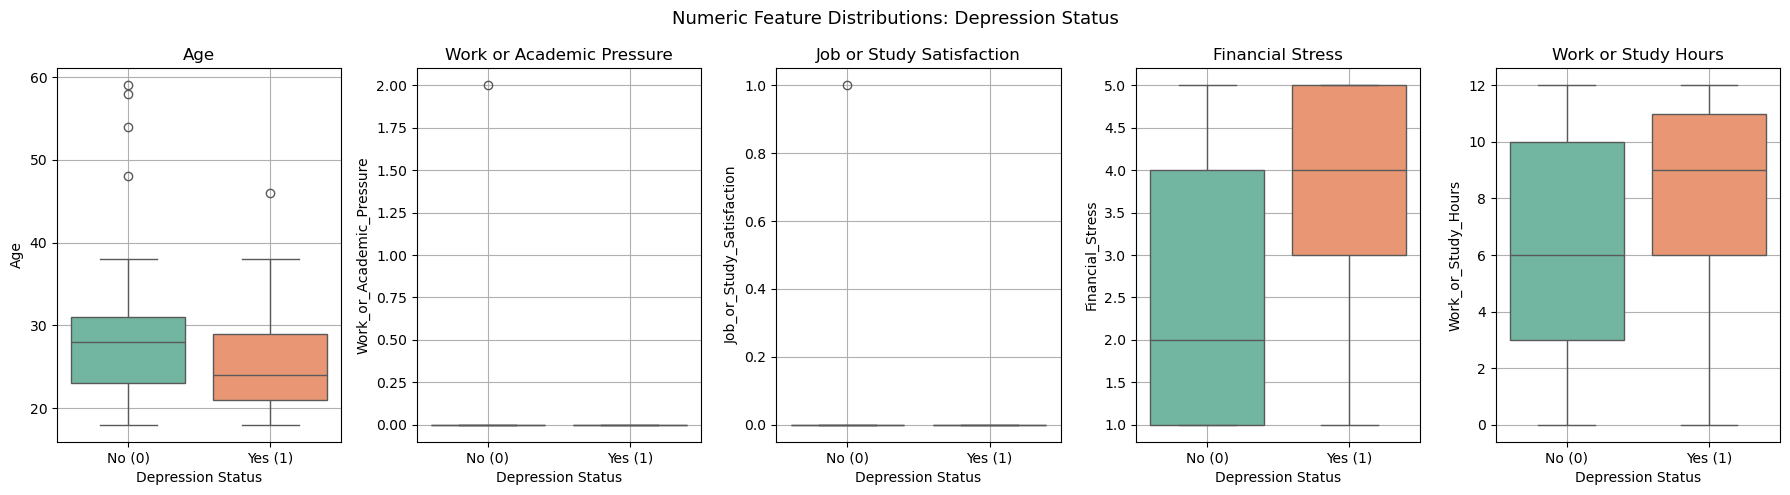

In [61]:
# Plot feature distributions by 'Depression' Status
numeric_features = ['Age', 'Work_or_Academic_Pressure', 'Job_or_Study_Satisfaction', 'Financial_Stress', 'Work_or_Study_Hours']

fig, axes = plt.subplots(1, len(numeric_features), figsize=(18, 5))
fig.suptitle('Numeric Feature Distributions: Depression Status', fontsize=13)

for ax, column in zip(axes, numeric_features):
    sns.boxplot(data=df_student_cleanup, x='Depression', y=column, ax=ax, hue='Depression', palette='Set2', legend=False)
    ax.set_title(column.replace('_', ' '))
    ax.set_xlabel('Depression Status')
    ax.set_xticks([0, 1])                        
    ax.set_xticklabels(['No (0)', 'Yes (1)'])    
    ax.grid(True)

plt.tight_layout()
plt.show()

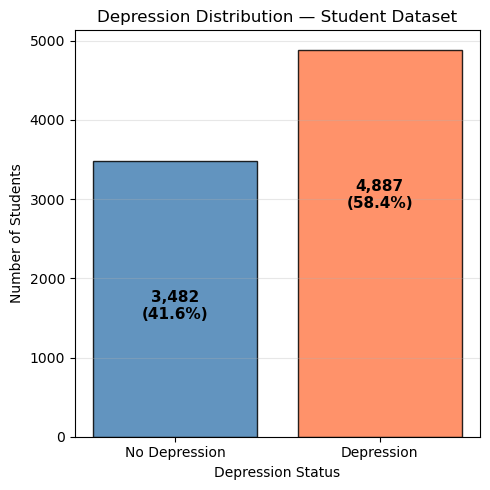

Overall depression rate: 58.4%


In [86]:
# --- Figure 1b: Overall Depression Rate in Student Dataset ---
fig, ax = plt.subplots(figsize=(5, 5))

depression_counts = df_student_cleanup['Depression'].value_counts()
depression_rate   = df_student_cleanup['Depression'].mean()

bars = ax.bar(
    ['No Depression', 'Depression'],
    [depression_counts[0], depression_counts[1]],
    color=['steelblue', 'coral'],
    edgecolor='black', alpha=0.85
)

ax.set_title('Depression Distribution — Student Dataset')
ax.set_ylabel('Number of Students')
ax.set_xlabel('Depression Status')
ax.grid(True, axis='y', alpha=0.3)

# Add count labels on top of bars
for bar, val in zip(bars, [depression_counts[0], depression_counts[1]]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() - 2000,
            f'{val:,}\n({val/len(df_student_cleanup):.1%})',
            ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Overall depression rate: {depression_rate:.1%}")

---
## Define X and y, Encode & Scale

In [87]:
##Rename
predictors = [
    "Gender",
    "Age",
    "Work_or_Academic_Pressure",
    "Job_or_Study_Satisfaction",
    "Sleep_Duration",
    "Dietary_Habits",
    "Suicidal_Thoughts",
    "Work_or_Study_Hours",
    "Financial_Stress",
    "Family_History_of_Mental_Illness"
]

X = df_student_cleanup[predictors]
y = df_student_cleanup["Depression"]

#dropping rows
df_clean = pd.concat([X, y], axis=1).dropna()
X = df_clean[predictors]
y = df_clean["Depression"]

print('X shape:',X.shape)
print('Y shape:',y.shape)

# One-hot encode categorical columns
# columns into numbers
X_encoded = pd.get_dummies(X, drop_first=True)
#print("p =",X_encoded.shape[1])
print(X_encoded.columns)
X_encoded.head()

X shape: (8369, 10)
Y shape: (8369,)
Index(['Age', 'Work_or_Academic_Pressure', 'Job_or_Study_Satisfaction',
       'Work_or_Study_Hours', 'Financial_Stress', 'Gender_Male',
       'Sleep_Duration_7-8 hours', 'Sleep_Duration_Less than 5 hours',
       'Sleep_Duration_More than 8 hours', 'Sleep_Duration_Others',
       'Dietary_Habits_Moderate', 'Dietary_Habits_Others',
       'Dietary_Habits_Unhealthy', 'Suicidal_Thoughts_Yes',
       'Family_History_of_Mental_Illness_Yes'],
      dtype='object')


,Age,Work_or_Academic_Pressure,Job_or_Study_Satisfaction,Work_or_Study_Hours,Financial_Stress,Gender_Male,Sleep_Duration_7-8 hours,Sleep_Duration_Less than 5 hours,Sleep_Duration_More than 8 hours,Sleep_Duration_Others,Dietary_Habits_Moderate,Dietary_Habits_Others,Dietary_Habits_Unhealthy,Suicidal_Thoughts_Yes,Family_History_of_Mental_Illness_Yes
0,27.0,0.0,0.0,5.0,5.0,False,True,False,False,False,False,False,True,True,False
1,19.0,0.0,0.0,9.0,1.0,True,False,False,True,False,False,False,True,True,False
2,19.0,0.0,0.0,2.0,3.0,True,False,True,False,False,False,False,True,True,False
3,26.0,0.0,0.0,12.0,5.0,False,False,True,False,False,False,False,True,True,False
4,24.0,0.0,0.0,11.0,1.0,True,False,False,True,False,False,False,True,True,True


In [88]:
#predictors
print("Number of predictors after encoding:", X_encoded.shape[1])
print('p =',X_encoded.shape[1])

Number of predictors after encoding: 15
p = 15


---
## Model 1 - Logistic Regression

In [89]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

demo_predictors = [
    "Gender",
    "Age",
    "Family_History_of_Mental_Illness"
]

X_demo = df_student_cleanup[demo_predictors]
y_demo = df_student_cleanup["Depression"]

df_demo = pd.concat([X_demo, y_demo], axis=1).dropna()

X_demo = df_demo[demo_predictors]
y_demo = df_demo["Depression"]

X_demo_encoded = pd.get_dummies(X_demo, drop_first=True)

log_demo = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)

demo_scores = cross_val_score(
    log_demo,
    X_demo_encoded,
    y_demo,
    cv=kf,
    scoring="accuracy"
)

print("Demographic Model CV Accuracy Scores:",  f"{demo_scores.mean():.3f}", "±", f"{demo_scores.std():.3f}")

Demographic Model CV Accuracy Scores: 0.617 ± 0.011


---
## Model 2 - Full regression model

In [90]:
log_full = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)

full_scores = cross_val_score(
    log_full,
    X_encoded,
    y,
    cv=kf,
    scoring="accuracy"
)

print("Full Model CV Accuracy:", f"{full_scores.mean():.3f}", "±", f"{full_scores.std():.3f}")

Full Model CV Accuracy: 0.809 ± 0.013


---
## Model 3 - KNN Comparasion

In [91]:
k_values = [3, 5, 10, 20, 50]
knn_results = []

for k in k_values:
    knn = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=k)
    )
    scores = cross_val_score(
        knn, 
        X_encoded, 
        y,
        cv=kf, 
        scoring="accuracy"
    )
    knn_results.append({
        "k": k,
        "Mean CV Accuracy": scores.mean(),
        "Std": scores.std()
    })
    
knn_results_df = pd.DataFrame(knn_results)
display(knn_results_df)
best_k = knn_results_df.loc[knn_results_df["Mean CV Accuracy"].idxmax(), "k"]
print(f"Best KNN: k={best_k} with accuracy {knn_results_df['Mean CV Accuracy'].max():.3f}")

,k,Mean CV Accuracy,Std
0,3,0.766876,0.012034
1,5,0.776436,0.010006
2,10,0.787907,0.008970
3,20,0.796869,0.006426
4,50,0.801528,0.009062


Best KNN: k=50 with accuracy 0.802


---
## Model 4 - Comparison Model Table

In [92]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression: Demographic Only",
        "Logistic Regression: Full Model",
        "KNN: k=3",
        "KNN: k=5",
        "KNN: k=10",
        "KNN: k=20",
        "KNN: k=50"
    ],
    "Mean CV Accuracy": [
        demo_scores.mean(),
        full_scores.mean(),
        knn_results_df.loc[knn_results_df["k"] == 3, "Mean CV Accuracy"].values[0],
        knn_results_df.loc[knn_results_df["k"] == 5, "Mean CV Accuracy"].values[0],
        knn_results_df.loc[knn_results_df["k"] == 10, "Mean CV Accuracy"].values[0],
        knn_results_df.loc[knn_results_df["k"] == 20, "Mean CV Accuracy"].values[0],
        knn_results_df.loc[knn_results_df["k"] == 50, "Mean CV Accuracy"].values[0]
    ],
    "Std": [
        demo_scores.std(),
        full_scores.std(),
        knn_results_df.loc[knn_results_df["k"]==3,  "Std"].values[0],
        knn_results_df.loc[knn_results_df["k"]==5,  "Std"].values[0],
        knn_results_df.loc[knn_results_df["k"]==10, "Std"].values[0],
        knn_results_df.loc[knn_results_df["k"]==20, "Std"].values[0],
        knn_results_df.loc[knn_results_df["k"]==50, "Std"].values[0],
    ]
})

model_results

,Model,Mean CV Accuracy,Std
0,Logistic Regression: Demographic Only,0.617397,0.010708
1,Logistic Regression: Full Model,0.808937,0.012817
2,KNN: k=3,0.766876,0.012034
3,KNN: k=5,0.776436,0.010006
4,KNN: k=10,0.787907,0.008970
5,KNN: k=20,0.796869,0.006426
6,KNN: k=50,0.801528,0.009062


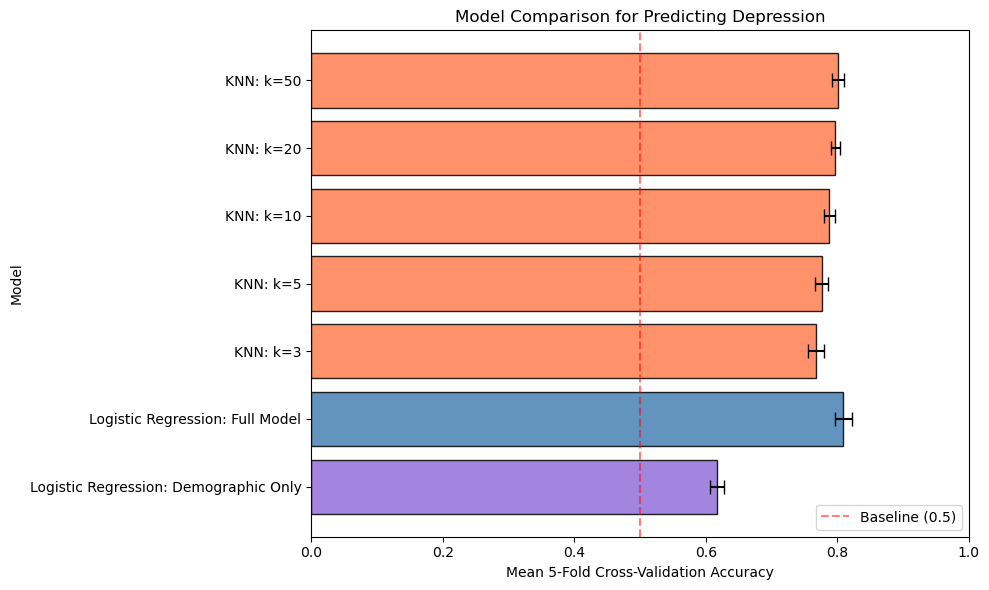

In [93]:
plt.figure(figsize=(10, 6))
bars = plt.barh(
    model_results["Model"],
    model_results["Mean CV Accuracy"],
    xerr=model_results["Std"],
    capsize=5,
    color=['mediumpurple', 'steelblue',
           'coral', 'coral', 'coral', 'coral', 'coral'],
    edgecolor='black', alpha=0.85
)

plt.xlabel("Mean 5-Fold Cross-Validation Accuracy")
plt.ylabel("Model")
plt.title("Model Comparison for Predicting Depression")
plt.xlim(0, 1)
plt.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Baseline (0.5)')
plt.legend()
plt.tight_layout()
plt.show()

---
## Fitting this model

In [100]:
final_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)

final_model.fit(X_encoded, y)
y_pred = final_model.predict(X_encoded)

print("=== Final Model: Full Logistic Regression ===")
print("Training Accuracy :", f"{accuracy_score(y, y_pred):.3f}")
print("Weighted F1 Score :", f"{f1_score(y, y_pred, average='weighted'):.3f}")
print()
print(classification_report(y, y_pred, target_names=['No Depression', 'Depression']))
print("Final model accuracy on full dataset:", accuracy_score(y, y_pred))

=== Final Model: Full Logistic Regression ===
Training Accuracy : 0.810
Weighted F1 Score : 0.809

               precision    recall  f1-score   support

No Depression       0.79      0.73      0.76      3482
   Depression       0.82      0.86      0.84      4887

     accuracy                           0.81      8369
    macro avg       0.81      0.80      0.80      8369
 weighted avg       0.81      0.81      0.81      8369

Final model accuracy on full dataset: 0.8102521209224519


---
## Logistic Regression Coefficients

In [95]:
log_reg = final_model.named_steps["logisticregression"]

coefficients = pd.DataFrame({
    "Predictor": X_encoded.columns,
    "Coefficient": log_reg.coef_[0]
})

coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()

coefficients_sorted = coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

coefficients_sorted.head(15)

,Predictor,Coefficient,Absolute Coefficient
13,Suicidal_Thoughts_Yes,1.201476,1.201476
4,Financial_Stress,0.806055,0.806055
12,Dietary_Habits_Unhealthy,0.525504,0.525504
3,Work_or_Study_Hours,0.500983,0.500983
0,Age,-0.487427,0.487427
7,Sleep_Duration_Less than 5 hours,0.190046,0.190046
10,Dietary_Habits_Moderate,0.169498,0.169498
14,Family_History_of_Mental_Illness_Yes,0.119243,0.119243
8,Sleep_Duration_More than 8 hours,-0.101853,0.101853
1,Work_or_Academic_Pressure,-0.033586,0.033586


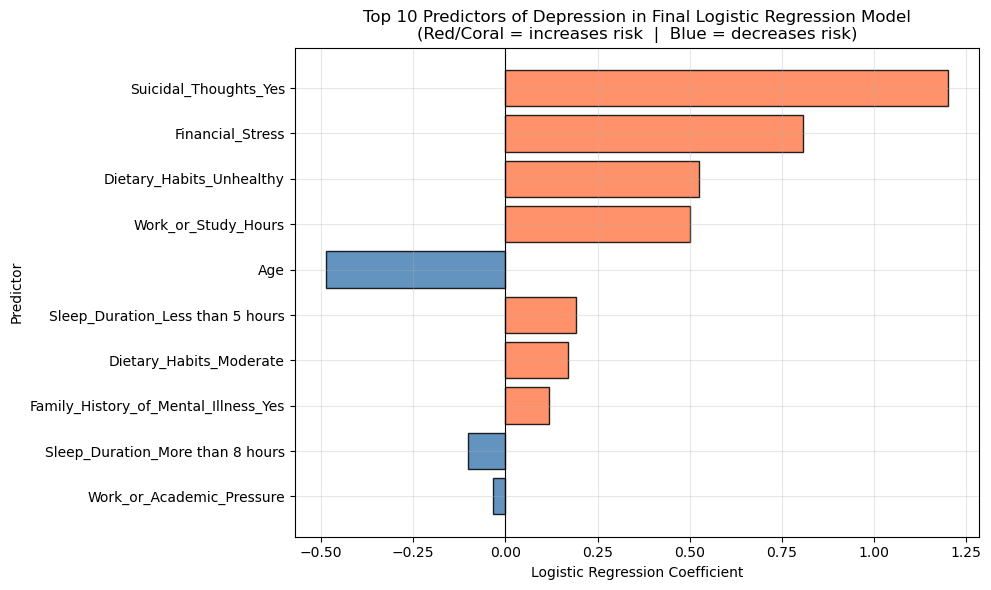

In [102]:
## Final Graph MODEL ESTIMATION
top_coefficients = coefficients_sorted.head(10)

colors = ['coral' if c > 0 else 'steelblue'
          for c in top_coefficients["Coefficient"]]

plt.figure(figsize=(10, 6))
plt.barh(top_coefficients["Predictor"],
         top_coefficients["Coefficient"],
         color=colors,        # ← add this
         edgecolor='black',   # ← add this
         alpha=0.85)          # ← add this
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Predictor")
plt.title("Top 10 Predictors of Depression in Final Logistic Regression Model\n(Red/Coral = increases risk  |  Blue = decreases risk)")
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

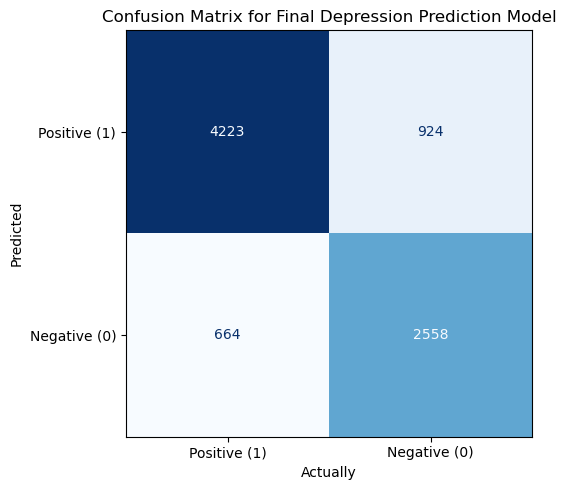

In [98]:
## Confusion Matrix
cm = confusion_matrix(y, y_pred)
TN = cm[0][0]  # 2,558
FP = cm[0][1]  # 924
FN = cm[1][0]  # 664
TP = cm[1][1]  # 4,223

cm_textbook = np.array([
    [TP, FP],   # Predicted Positive row
    [FN, TN]    # Predicted Negative row
])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_textbook,
    display_labels=["Positive (1)", "Negative (0)"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format='d', colorbar=False, cmap='Blues')

# Fix axis labels
ax.set_xlabel("Actually")
ax.set_ylabel("Predicted")
ax.set_title("Confusion Matrix for Final Depression Prediction Model")

plt.tight_layout()
plt.show()

In [83]:
print("=" * 60)
print("            FINAL RESULTS SUMMARY")
print("=" * 60)
print(model_results.to_string(index=False))
print("=" * 60)
print(f"\nSelected final model : Full Logistic Regression")
print(f"Reason               : Highest CV accuracy, interpretable coefficients")
print(f"Training accuracy    : {accuracy_score(y, y_pred):.3f}")
print(f"Weighted F1 score    : {f1_score(y, y_pred, average='weighted'):.3f}")
print(f"\nHypothesis result:")
print(f"  Demographic-only accuracy : {demo_scores.mean():.3f}")
print(f"  Full model accuracy       : {full_scores.mean():.3f}")
print(f"  → Full model outperforms demographic-only by {(full_scores.mean()-demo_scores.mean()):.3f}")

            FINAL RESULTS SUMMARY
                                Model  Mean CV Accuracy      Std
Logistic Regression: Demographic Only          0.617397 0.010708
      Logistic Regression: Full Model          0.808937 0.012817
                             KNN: k=3          0.766876 0.012034
                             KNN: k=5          0.776436 0.010006
                            KNN: k=10          0.787907 0.008970
                            KNN: k=20          0.796869 0.006426
                            KNN: k=50          0.801528 0.009062

Selected final model : Full Logistic Regression
Reason               : Highest CV accuracy, interpretable coefficients
Training accuracy    : 0.810
Weighted F1 score    : 0.809

Hypothesis result:
  Demographic-only accuracy : 0.617
  Full model accuracy       : 0.809
  → Full model outperforms demographic-only by 0.192
